# Taller 5: Filtros Lineales y No Lineales

**Profesor**: PhD Juan Pablo Reyes

**Autores**: Estefanía Laverde, Harvy Benitez.

**Nota:** Se declara el uso de ChatGPT en la elaboración de la versión final de este Taller. Siguiendo la recomendación del profesor, se utilizó como base el código provisto en el enlace del Taller 5, dado que este facilita implementaciones específicas que resultan innecesariamente complejas cuando se generan desde cero con una herramienta de IA. Se declara además el uso de IA generativa para encontrar la forma de implementar la corrección de iluminación del punto de síntesis, pero siempre respetando utilizar únicamente las funciones y herramientas de clase.

La IA generativa fue empleada principalmente para mejorar la redacción de los párrafos de algunas respuestas, pero haciendo el análisis por cuenta propia.

## 1. Filtro promedio

### 1.1 Cree una nueva sección en su notebook
### 1.2 Cargue la imagen de trabajo med.png
### 1.3 Visualice la imagen y su histograma

In [3]:
# librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import time

from skimage import exposure
from skimage.morphology import footprint_rectangle
from skimage.filters.rank import mean
from skimage.filters import gaussian
from scipy.ndimage import convolve
from skimage.util import random_noise
from scipy.ndimage import generic_filter
from skimage.filters.rank import median
from skimage.morphology import disk, ball
from skimage.filters.rank import majority
from skimage.filters.rank import maximum
from skimage.filters.rank import minimum
from skimage.filters.rank import modal
from skimage.filters.rank import geometric_mean

In [4]:
# path de imagenes
images_path = "images/"

os.listdir(images_path)

['FISSURE.png', 'IMPACT.png', 'MORPHO.png', 'MEB.png', 'noised_circuit.png']

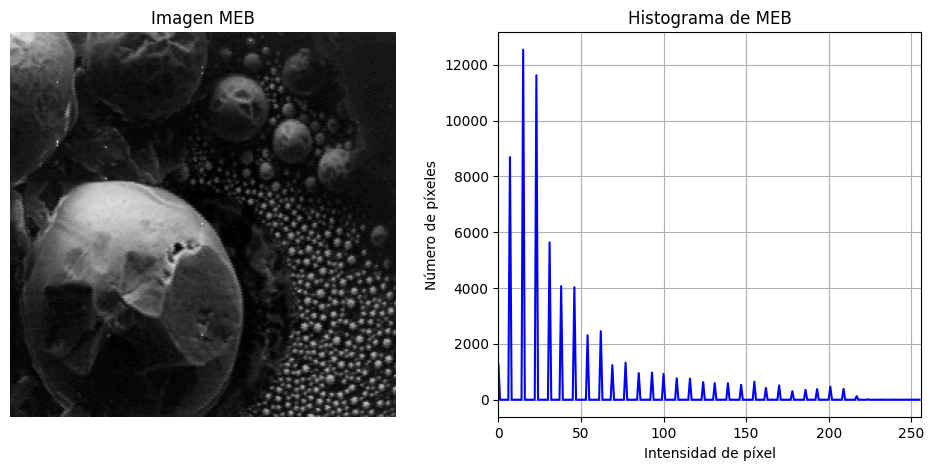

In [4]:
# cargar imagen meb.png
meb_image = cv2.imread(images_path + "MEB.png", cv2.IMREAD_GRAYSCALE)

# calcular el histograma 
hist_meb = cv2.calcHist([meb_image], [0], None, [256], [0, 256])

# visualizar
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(meb_image, cmap='gray')
plt.title("Imagen MEB")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.plot(hist_meb, color='blue')
plt.title("Histograma de MEB")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.xlim([0, 256])
plt.grid()
plt.show()

In [5]:
grises = np.unique(meb_image)
print(f"Niveles de gris diferentes: {len(grises)}")
print(f"Los niveles de gris son: {grises}")

Niveles de gris diferentes: 34
Los niveles de gris son: [  0   7  15  23  31  38  46  54  62  69  77  85  93 100 108 116 124 131
 139 147 155 162 170 178 186 193 201 209 217 224 232 240 248 255]


### 1.4 Describa su forma: ¿es continuo/discontinuo? ¿Cuántos niveles de gris diferentes tiene? ¿Cuáles son estos niveles de gris?

El histograma de la imagen MEB muestra discontinuidades entre los tonos de gris, indicando que la imagen original tuvo un proceso de transformación o cuantización que limitó los niveles de gris presentes. Los tonos prevalecientes se encuentren en valores de intensidad bajos, en torno a 0 y 60 aproximadamente. La forma del histograma presenta un pico pronunciado que decrece de manera gradual hacia los niveles de gris más altos, recordándonos a los histogramas obtenidos cuando hay presente ruido de tipo Rayleigh.

Para determinar cuántos niveles de gris diferentes tiene la imagen, se usa la función `np.unique()` sobre la matriz de la imagen. Los resultados de esta función nos indican que solo 34 tonos de gris son presentados en la imagen, siendo estos los siguientes: [  0   7  15  23  31  38  46  54  62  69  77  85  93 100 108 116 124 131 139 147 155 162 170 178 186 193 201 209 217 224 232 240 248 255]



### 1.5 Partiendo del histograma, deduzca con cuántos bits ha sido numerizada esta imagen.

A partir del análisis del histograma y de los niveles de gris proporcionados, se deduce que la imagen fue originalmente con 8 bits, pues entre los valores están presentes los extremos 0 y 255, que corresponden a los valores mínimo y máximo de intensidad en una imagen de 8 bits. 

### 1.6 Aplique un filtro promedio utilizando una máscara de tamaño 3x3 a esta imagen. Cualitativamente, ¿cómo es la imagen resultado?

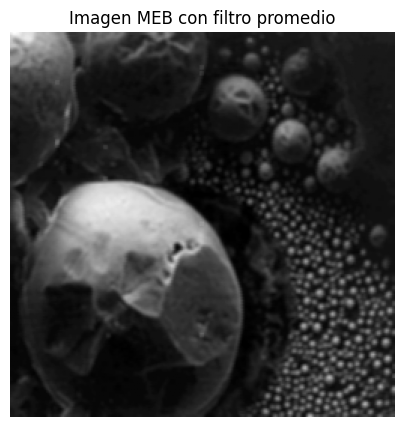

In [6]:
# aplicar filtro promedio
mean_meb = mean(meb_image, footprint_rectangle((3,3)))

# visualizar
plt.figure(figsize=(8, 5))
plt.imshow(mean_meb, cmap='gray')
plt.title("Imagen MEB con filtro promedio")
plt.axis('off')
plt.show()

El filtro promedio aplicado sobre la imagen opera mediante una convolución que calcula la media aritmética de los NxN (en este caso, 3x3) píxeles vecinos para cada píxel de la imagen. Este proceso genera un efecto de suavizado, que a nivel visual se traduce en una imagen con bordes menos definidos y una apariencia borrosa, especialmente en las áreas de transición entre regiones de diferente intensidad. Notamos también que, al usar un kernel de tamaño pequeño, las estructuras de menor tamaño en la imagen se mantienen reconocibles.

### 1.7 Visualice el histograma de esta nueva imagen, y compárelo con el histograma de la imagen original (forma general, altura de los picos, ...).

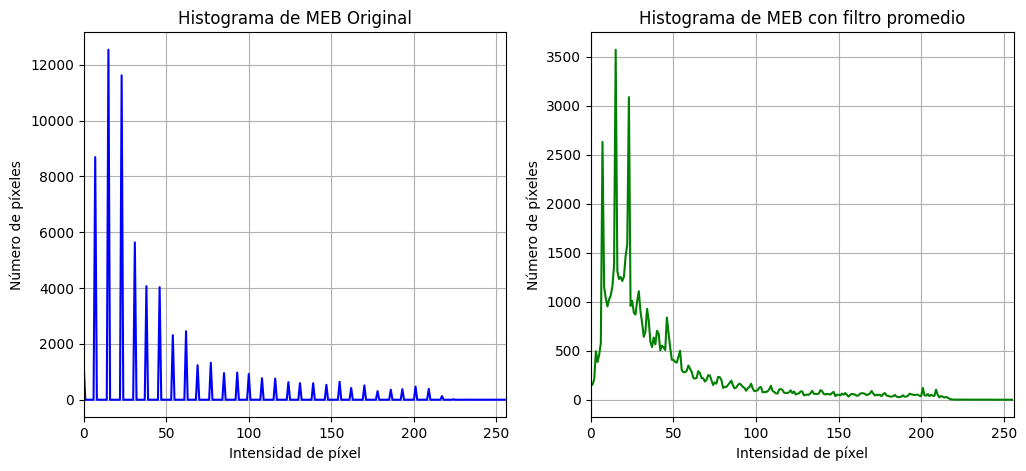

In [7]:
# histograma de la imagen con filtro promedio
hist_mean_meb = cv2.calcHist([mean_meb], [0], None, [256], [0, 256])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_meb, color='blue')
plt.title("Histograma de MEB Original")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.xlim([0, 256])
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(hist_mean_meb, color='green')
plt.title("Histograma de MEB con filtro promedio")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.xlim([0, 256])
plt.grid()
plt.show()

In [8]:
print(f"Niveles de gris diferentes en la imagen con filtro promedio: {len(np.unique(mean_meb))}")

Niveles de gris diferentes en la imagen con filtro promedio: 231


El histograma resultante de la imagen filtrada con el filtro promedio muestra una distribución más uniforme de los niveles de gris, con una reducción significativa del número de píxeles en los picos que se encontraban en el histograma original. Esto se produce debido a que, al calcular el promedio entre los píxeles vecinos, se suavizan las transiciones abruptas entre los niveles de gris. Notamos que además pasa de ser un histograma de aparencia discontinua a uno más continuo. Lo podemos comprobar obteniendo el número de niveles de gris diferentes en la imagen filtrada, el cual es de 231 valores, en comparación con los 34 usados en la imagen original.

### 1.8 Calcule la imagen de diferencia con la original. Justifique el resultado obtenido (¿en cuáles regiones de la imagen son visibles las diferencias?, ¿por qué?).

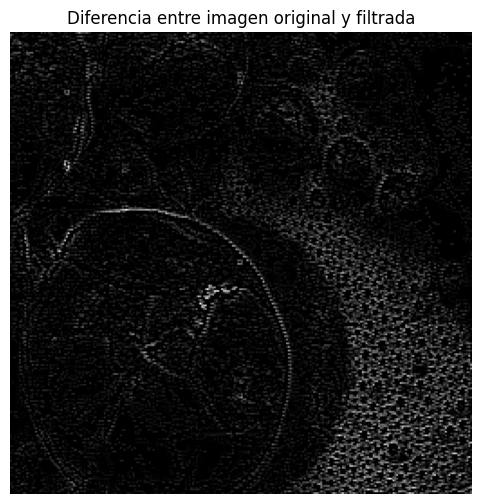

In [10]:
# filtrada - original
substraction = cv2.subtract(mean_meb, meb_image)

plt.figure(figsize=(6, 6))
plt.imshow(substraction, cmap='gray')
plt.title("Diferencia entre imagen original y filtrada")
plt.axis('off')
plt.show()

Las diferencias más visibles entre la imagen original y la filtrada se encuentran en las regiones no uniformes de la imagen, como pueden ser bordes o áreas con distintas texturas. Esto se debe, nuevamente, a que el filtro promedio suaviza las transiciones entre los niveles de gris, haciendo que tanto bordes como texturas pierdan definición y se vuelvan más borrosos. En contraste, las regiones más uniformes de la imagen no presentan diferencias tan marcadas, ya que el valor promedio de los píxeles vecinos en estas áreas no varía tanto respecto a los valores originales.

### 1.9 Ahora filtre la imagen original con un filtro promedio utilizando una máscara de tamaño 5x5. Paralelamente, filtre la imagen original, aplicando consecutivamente sobre esta, dos filtros promedio de tamaño 3x3. Haga una evaluación visual de los resultados: ¿las dos imágenes obtenidas son idénticas? ¿por qué? ¿cuál de los dos tratamientos suprime mejor los cambios de nivel de gris de la imagen?

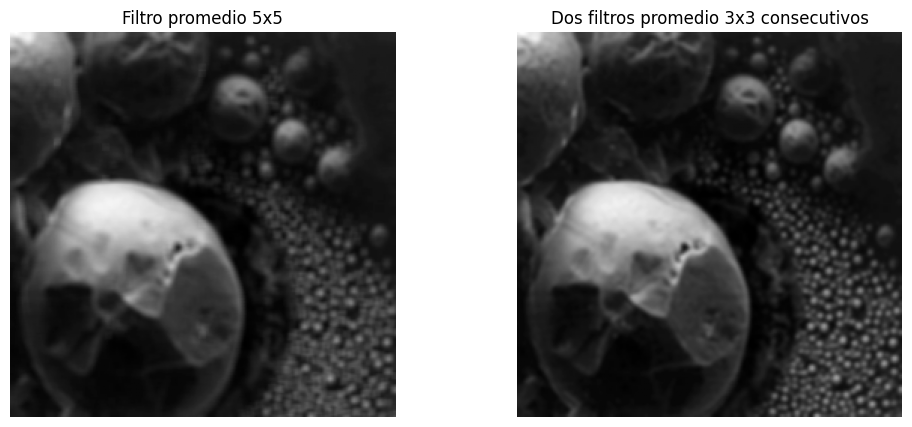

Los filtros son iguales? False


In [11]:
# filtro promedio con máscara 5x5
mean_meb_5x5 = mean(meb_image, footprint_rectangle((5,5)))

# aplicar dos filtros promedio de tamaño 3x3 consecutivamente
mean_meb_3x3_1 = mean(meb_image, footprint_rectangle((3,3)))
mean_meb_3x3_2 = mean(mean_meb_3x3_1, footprint_rectangle((3,3)))

# visualizar filtro 5x5 y dos filtros 3x3 consecutivos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(mean_meb_5x5, cmap='gray')
plt.title("Filtro promedio 5x5")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mean_meb_3x3_2, cmap='gray')
plt.title("Dos filtros promedio 3x3 consecutivos")
plt.axis('off')
plt.show()

print(f"Los filtros son iguales? {np.array_equal(mean_meb_5x5, mean_meb_3x3_2)}")

Las imágenes obtenidas al aplicar un filtro promedio de tamaño 5x5 y al aplicar consecutivamente dos filtros promedio de 3x3 no son idénticas: si bien ambos tratamientos suavizan la imagen, el filtro de 5x5 genera un efecto más agresivo, resultando en contornos más borrosos y una mayor pérdida de detalles. Esto se debe a que el filtro de 5x5 asigna el mismo peso a todos los píxeles de un área mayor, lo que reduce drásticamente la variabilidad local. En contraste, aplicar dos filtros de 3x3 de forma consecutiva suaviza la imagen de manera más gradual; aunque el área total afectada termina siendo de 5x5 (pues el primer paso de 3x3 hace que los píxeles tomen infomación de sus 8 vecinos y al pasar el segundo filtro la información de los vecinos tendrá la información de sus vecinos más cercanos, afectando una cuadrícula de 5x5), el proceso por etapas hace que los píxeles centrales conserven una mayor influencia en el promedio final. De este modo, la variación de los valores ocurre en una magnitud menor y más controlada, logrando un difuminado que respeta mejor la estructura original de la imagen en comparación con el filtro de 5x5.

Teniendo estas consideraciones en cuenta, aplicar un filtro promedio de 5x5 suprime mejor los cambios de niveles de gris, con la contraparte de que también borra más detalles, mientras que aplicar dos filtros de 3x3 consecutivos ofrece un equilibrio entre suavizado y conservación de detalles, aunque con una supresión de cambios de niveles de gris menos pronunciada.

### 1.10 Convolucionar una imagen dos veces con una misma máscara equivale a hacer una sola convolución con otra máscara, obtenida por convolución de la máscara inicial con ella misma. ¿Cuál es entonces la máscara resultante de la convolución de la máscara del filtro promedio 3x3 con ella misma? ¿Cómo es la máscara del filtro promedio 5x5? Con base en la forma de estas dos máscaras, justifique los resultados visuales obtenidos en el punto anterior.

La máscara resultante de la convolución de la máscara del filtro promedio 3x3 con ella misma es una máscara 5x5 calculada de la siguiente forma:
1. Añadir un padding a la máscara original de 3x3 para convertirla en una máscara de 5x5, rellenando con ceros los valores fuera de la máscara original:
```
0 0 0 0 0
0 1 1 1 0
0 1 1 1 0
0 1 1 1 0
0 0 0 0 0
```
2. Convolucionar esta máscara con ella misma, lo que implica calcular el valor de cada posición de la nueva máscara 5x5 sumando los productos de los valores correspondientes de las dos máscaras. El resultado de esta convolución es la siguiente máscara 5x5 (los valores del padding, al pasar por la máscara, es como si tuvieran valores 0 alrededor):
```
1 2 3 2 1
2 4 6 4 2
3 6 9 6 3
2 4 6 4 2
1 2 3 2 1
```
3. Al usar la máscara obtenida, se normaliza dividiendo entre 81 (la suma de todos los valores de la máscara).

Por otro lado, la máscara del filtro promedio 5x5 es una matriz de 1s, normalizada dividiendo entre 25:
```
1 1 1 1 1
1 1 1 1 1
1 1 1 1 1
1 1 1 1 1
1 1 1 1 1
```

Notamos entonces que los resultados obtenidos son muy diferentes, pues en la máscara obtenida al convolucionar la máscara de 3x3 con ella misma, los píxeles centrales tienen un peso mucho mayor que los periféricos, haciendo que el suavizado sea más gradual y respetoso con la estructura original de la imagen, mientras que en la máscara del filtro promedio 5x5, todos los píxeles tienen el mismo peso, lo que genera un efecto de suavizado más agresivo y uniforme, resultando en una mayor pérdida de detalles y una imagen más borrosa.


### 1.11 Por último, filtre la imagen original con un filtro promedio utilizando una máscara de tamaño 25x25. Haga una evaluación visual del resultado: ¿qué objetos de la imagen original se conservaron?¿qué sucedió con las estructuras pequeñas presentes en la imagen original?¿por qué?

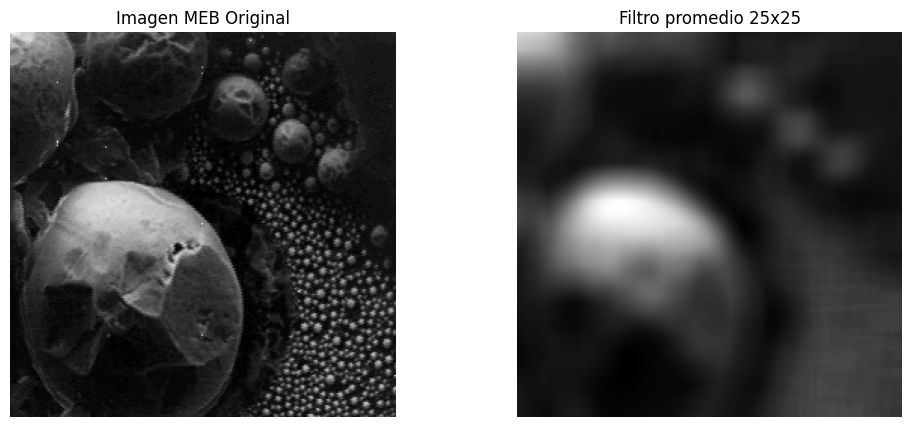

In [28]:
# filtro promedio tamaño 25x25
mean_meb_25x25 = mean(meb_image, footprint_rectangle((25,25)))

# visualizar imagen original y filtro
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(meb_image, cmap='gray')
plt.title("Imagen MEB Original")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mean_meb_25x25, cmap='gray')
plt.title("Filtro promedio 25x25")
plt.axis('off')
plt.show()

Al aplicar el filtro promedio con un tamaño de máscara de 25x25, se conservan únicamente las estructuras más grandes de la imagen original. Esto sucede porque el filtro de 25x25 toma el promedio de un área mucho mayor al área que ocupan los detalles pequeños, luego, al calcular el promedio, estos detalles se pierden completamente con su entorno. En general, el tamaño de la máscara determina qué detalles se conservan: mientras más grande sea la máscara, más detalles pequeños se perderán, y solo las estructuras grandes serán visibles.

### 1.12 Cargue ahora la imagen impact.png

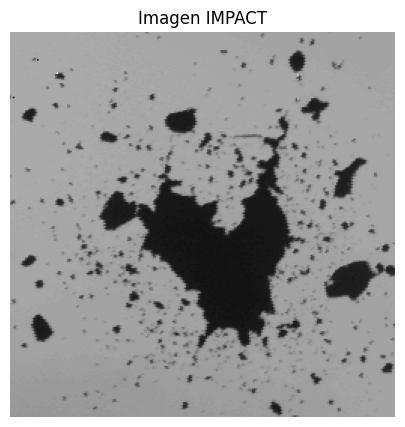

In [12]:
impact_image = cv2.imread(images_path + "IMPACT.png", cv2.IMREAD_GRAYSCALE)

# visualizar imagen impact
plt.figure(figsize=(8, 5))
plt.imshow(impact_image, cmap='gray')
plt.title("Imagen IMPACT")
plt.axis('off')
plt.show()

### 1.13 Aplique a esta imagen un filtro promedio con una máscara de tamaño 5x5 usando una convolución. Visualice el resultado.

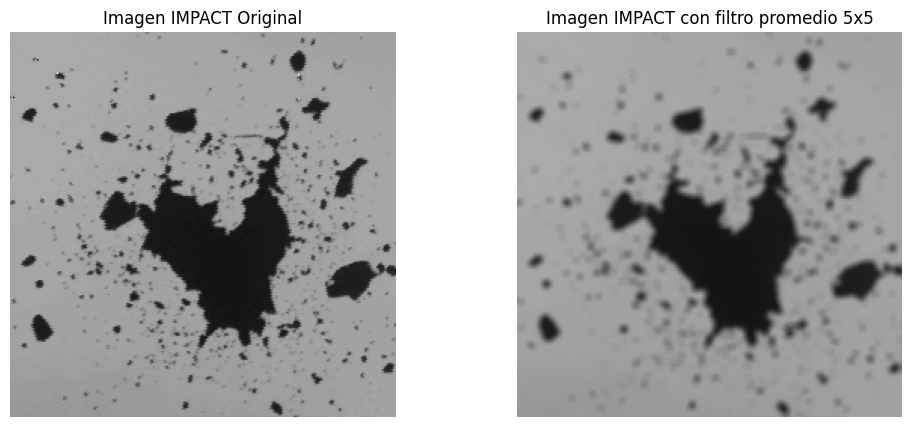

In [13]:
# filtro promedio con máscara 5x5
mean_impact_5x5 = mean(impact_image, footprint_rectangle((5,5)))

# visualizar imagen original y filtro
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(impact_image, cmap='gray')
plt.title("Imagen IMPACT Original")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mean_impact_5x5, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen IMPACT con filtro promedio 5x5")
plt.axis('off')
plt.show()

### 1.14 Ahora aplique a la imagen original un filtro gaussiano con una máscara de tamaño 5x5 usando una convolución. Visualice el resultado.

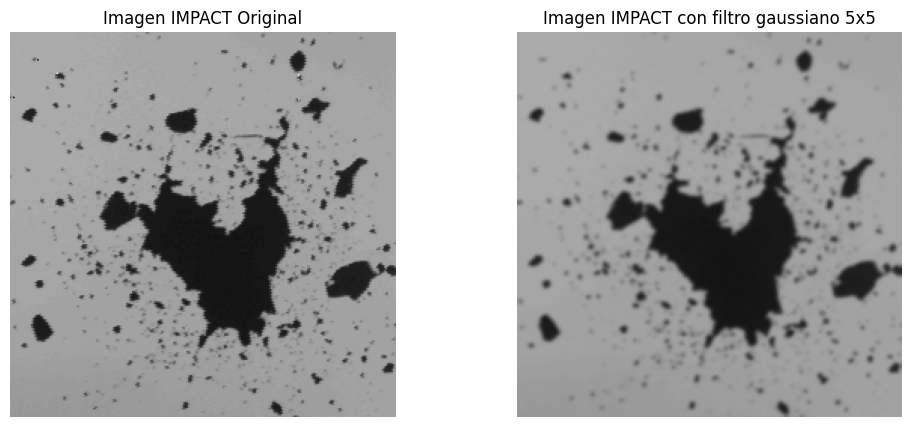

In [14]:
# filtro gaussiano con máscara 5x5
impact_gaussian = cv2.GaussianBlur(impact_image, (5, 5), 0) # sigma=0 para que se calcule automáticamente a partir del tamaño de la máscara

# visualizar imagen original y filtro gaussiano
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(impact_image, cmap='gray')
plt.title("Imagen IMPACT Original")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(impact_gaussian, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen IMPACT con filtro gaussiano 5x5")
plt.axis('off')
plt.show()

### 1.15 Calcule la diferencia de los resultados de los dos filtros. Visualice el resultado. Justifique el resultado obtenido (¿en cuáles regiones de la imagen son visibles las diferencias?, ¿por qué?...).

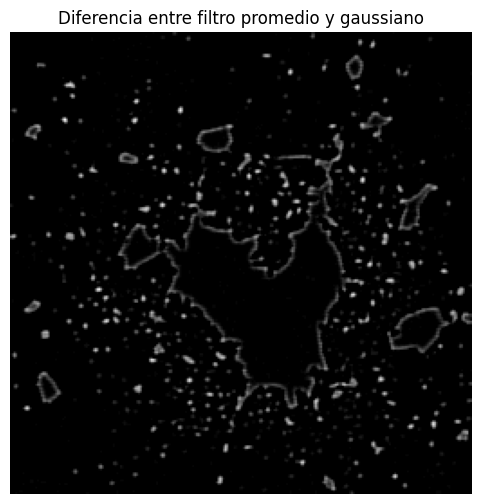

In [16]:
# diferencia entre filtro promedio y gaussiano
substraction = cv2.subtract(mean_impact_5x5, impact_gaussian)

# visualizar la diferencia
plt.figure(figsize=(6, 6))
plt.imshow(substraction, cmap='gray')
plt.title("Diferencia entre filtro promedio y gaussiano")
plt.axis('off')
plt.show()

Las diferencias son principalmente visibles en los contornos de la figura presente en la imagen. Esto se debe a que el filtro gaussiano, a diferencia del filtro promedio, asigna pesos mayores a los píxeles cercanos al centro de la máscara, y pesos menores a los píxeles a medida que se alejan del centro. Esto hace que, a pesar de que el tamaño del kernel es el mismo para ambos, el filtro gaussiano preserve de mejor manera los bordes y detalles, como se ve en las imagenes obtenidas y se confirma en la imagen de diferencias.

### 1.16 ¿En qué casos (características de las imágenes) preferiría utilizar un filtro promedio a un filtro gaussiano y visceversa?

La elección del filtro depende tanto de las características de la imagen como del objetivo del procesamiento:
- Filtro Promedio: es preferible para un suavizado general en escenas con ruido homogéneo. Resulta muy efectivo para resaltar estructuras de gran escala, aunque a costa de difuminar contornos y perder detalles finos. Su simplicidad computacional lo hace ideal para aplicaciones con recursos limitados o donde la prioridad es simplificar la imagen hacia sus formas principales.

- Filtro Gaussiano: es la opción adecuada cuando se busca reducir el ruido preservando la integridad de los bordes y las estructuras detalladas. Al aplicar pesos ponderados, genera transiciones más naturales y mantiene mejor la forma original de los objetos en la imagen. Aunque requiere mayor capacidad de cómputo que el promedio, su equilibrio entre reducción de ruido y preservación de detalles lo vuelve una buena alternativa para imágenes con texturas complejas o donde la claridad de los bordes es crucial.

## 2. Filtros lineales separables

### 2.1 Cree una nueva sección en su notebook
### 2.2 Cargue la imagen meb.png y remuestréela para obtener una imagen de tamaño 2048x2048.

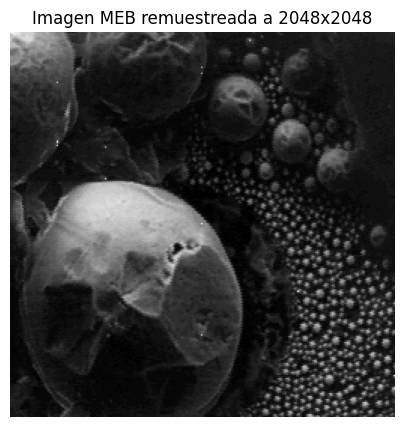

In [9]:
# cargar imagen meb
meb_image = cv2.imread(images_path + "MEB.png", cv2.IMREAD_GRAYSCALE)

# remuestrear con vecino más cercano
meb_resized =  cv2.resize(meb_image, (2048,2048), interpolation=cv2.INTER_NEAREST)

# visualizar imagen remuestreada
plt.figure(figsize=(8, 5))
plt.imshow(meb_resized, cmap='gray')
plt.title("Imagen MEB remuestreada a 2048x2048")
plt.axis('off')
plt.show()

### 2.3 Aplique un filtros promedio de 3x3 a la imagen usando una convolución. Realice varias ejecuciones y mida el tiempo de las mismas.

In [83]:
# fijamos el número de ejecuciones (para este y demás experimentos) y el kernel ya normalizado
num_ejecuciones = 100
kernel = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]])

times_convolve = []
for _ in range(num_ejecuciones):
    start_time = time.time()
    mean_meb_convolve = convolve(meb_resized, kernel, mode='constant', cval=0.0)
    end_time = time.time()
    times_convolve.append(end_time - start_time)

print(f"Tiempo promedio de ejecución con convolve kernel 3x3: {np.mean(times_convolve):.4f} segundos")

Tiempo promedio de ejecución con convolve kernel 3x3: 0.0193 segundos


### 2.4 Aplique un filtro promedio de 3x1 sobre la imagen de trabajo y luego un filtro promedio de 1x3 usando una convolución. Realice varias ejecuciones y mida el tiempo de las mismas.

In [84]:
kernel_3x1 = np.ones((3, 1)) 
kernel_1x3 = np.ones((1, 3)) 

times_3x1_1x3 = []
for _ in range(num_ejecuciones):
    start_time = time.time()
    mean_meb_3x1 = convolve(meb_resized, kernel_3x1, mode='constant', cval=0)
    end_time = time.time()
    time_3x1 = end_time - start_time

    start_time = time.time()
    mean_meb_3x1_w_1x3 = convolve(mean_meb_3x1, kernel_1x3, mode='constant', cval=0)
    end_time = time.time()
    time_1x3 = end_time - start_time
    times_3x1_1x3.append(time_3x1 + time_1x3)

print(f"Tiempo promedio de ejecución con kernel 3x1 seguido de 1x3: {np.mean(times_3x1_1x3):.4f} segundos")

Tiempo promedio de ejecución con kernel 3x1 seguido de 1x3: 0.0263 segundos


### 2.5 Grafique el resultado comparativo de los tiempos de ejecución para los puntos anteriores.

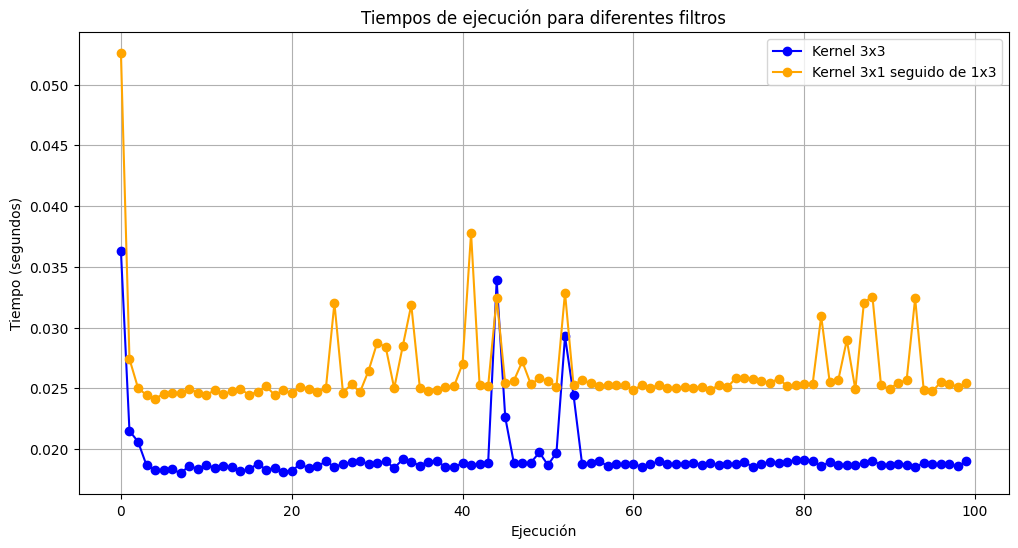

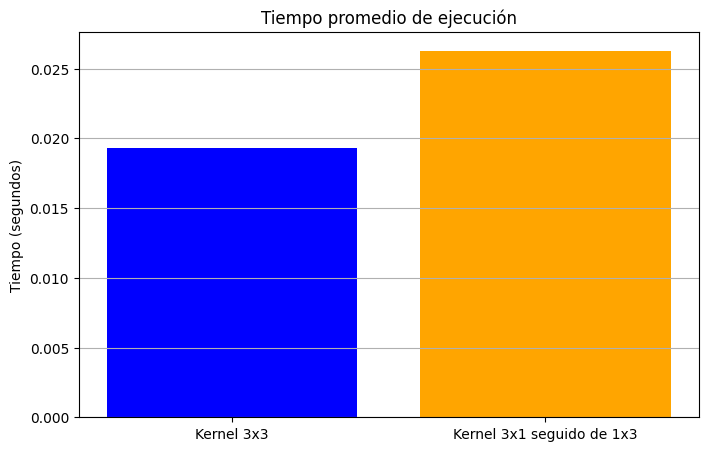

In [85]:
# plotear gráficos para cada ejecución
plt.figure(figsize=(12, 6))
plt.plot(times_convolve, label='Kernel 3x3', marker='o', color='blue')
plt.plot(times_3x1_1x3, label='Kernel 3x1 seguido de 1x3', marker='o', color='orange')
plt.title("Tiempos de ejecución para diferentes filtros")
plt.xlabel("Ejecución")
plt.ylabel("Tiempo (segundos)")
plt.legend()
plt.grid()
plt.show()

# plotear barras con el tiempo promedio
plt.figure(figsize=(8, 5))
labels = ['Kernel 3x3', 'Kernel 3x1 seguido de 1x3']
times_avg = [np.mean(times_convolve), np.mean(times_3x1_1x3)]
plt.bar(labels, times_avg, color=['blue', 'orange'])
plt.title("Tiempo promedio de ejecución")
plt.ylabel("Tiempo (segundos)")
plt.grid(axis='y')
plt.show()

### 2.6 Efectúe una sustracción de estas imágenes para corroborar el resultado Las dos imágenes resultantes, ¿son idénticas? 

In [ ]:
# sustracción de las imágenes obtenidas 2 a 2
diff = cv2.subtract(mean_meb_3x1_w_1x3, mean_meb_convolve)
np.unique(diff)

array([0], dtype=uint8)

La sustracción los resultados de ambos métodos producen exactamente la misma imagen (diferencia es 0 en todos los píxeles), lo que confirma que ambos métodos de filtrado (convolución directa con un kernel 3x3 y convolución secuencial con kernels 3x1 y 1x3) son equivalentes en términos de resultado final, aunque difieren en términos de eficiencia computacional.

### 2.7 Revise la siguiente explicación en separabilidad de filtros lineales. Explique la diferencia de los tiempos de ejecución determinando el número de operaciones elementales (SUMA, RESTA) efectuadas por las dos versiones del filtro. 

La diferencia en los tiempos de ejecución entre ambas versiones del filtro se explica analizando el número de operaciones elementales requeridas por cada píxel de la imagen. En una convolución estándar de $3 \times 3$, se deben realizar 9 multiplicaciones y 8 sumas (un total de 17 operaciones por píxel), ya que el kernel procesa toda la vecindad en cada paso. Al calcular el número de operaciones con el tamaño de la imagen se obtiene: $17 \times 2048 \times 2048 =$ **71,303,168 operaciones**.

Por el contrario, al emplear la propiedad de separabilidad con kernels de $3 \times 1$ y $1 \times 3$, el número de operaciones se reduce a 6 multiplicaciones y 4 sumas (un total de 10 operaciones por píxel), que para el total de la imagen se traduce en $10 \times 2048 \times 2048 =$ **41,943,040 operaciones**.

Teóricamente, esta reducción del costo computacional debería traducirse en una ejecución más rápida, sin embargo, en este experimento el beneficio no alcanza a notarse debido a que el tamaño del filtro es extremadamente pequeño, luego el tiempo está predominantemente influenciado por la carga y lectura de resultados en memoria.

Si repetimos el experimento con un filtro de mayor tamaño se pueden visualizar de mejor manera las diferencias en tiempos de ejecución:

In [86]:
# fijamos el número de ejecuciones (para este y demás experimentos) y el kernel ya normalizado
num_ejecuciones = 100
kernel = np.ones((9, 9))

times_convolve = []
for _ in range(num_ejecuciones):
    start_time = time.time()
    mean_meb_convolve = convolve(meb_resized, kernel, mode='constant', cval=0.0)
    end_time = time.time()
    times_convolve.append(end_time - start_time)

print(f"Tiempo promedio de ejecución con convolve kernel 9x9: {np.mean(times_convolve):.4f} segundos")

kernel_9x1 = np.ones((9, 1)) 
kernel_1x9 = np.ones((1, 9)) 

times_9x1_1x9 = []
for _ in range(num_ejecuciones):
    start_time = time.time()
    mean_meb_9x1 = convolve(meb_resized, kernel_9x1, mode='constant', cval=0)
    end_time = time.time()
    time_9x1 = end_time - start_time

    start_time = time.time()
    mean_meb_9x1_w_1x9 = convolve(mean_meb_9x1, kernel_1x9, mode='constant', cval=0)
    end_time = time.time()
    time_1x9 = end_time - start_time
    times_9x1_1x9.append(time_9x1 + time_1x9)

print(f"Tiempo promedio de ejecución con kernel 9x1 seguido de 1x9: {np.mean(times_9x1_1x9):.4f} segundos")

Tiempo promedio de ejecución con convolve kernel 9x9: 0.1937 segundos
Tiempo promedio de ejecución con kernel 9x1 seguido de 1x9: 0.0396 segundos


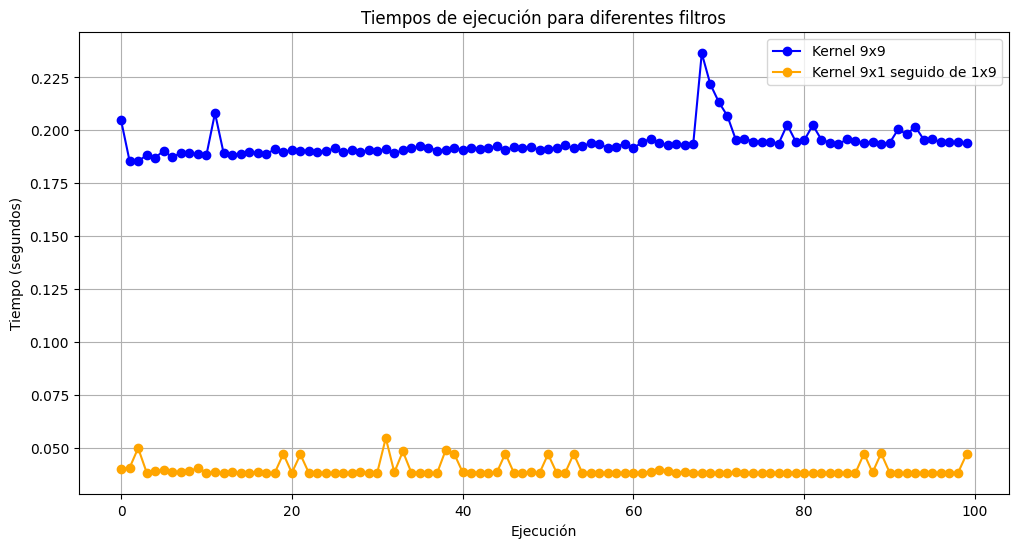

In [87]:
# plotear gráficos para cada ejecución
plt.figure(figsize=(12, 6))
plt.plot(times_convolve, label='Kernel 9x9', marker='o', color='blue')
plt.plot(times_9x1_1x9, label='Kernel 9x1 seguido de 1x9', marker='o', color='orange')
plt.title("Tiempos de ejecución para diferentes filtros")
plt.xlabel("Ejecución")
plt.ylabel("Tiempo (segundos)")
plt.legend()
plt.grid()
plt.show()

### 2.8 Calcule la duración de ejecución que se debería obtener con un filtro promedio 10 veces más grande (es decir de tamaño 30x30). Verifique este resultado experimentalmente e intente explicar el tiempo de cálculo observado (pensando en los métodos de optimización utilizables con el filtro promedio separable).

El tiempo de ejecución promedio para el filtro de 3x3 es de 0.0193 segundos, y el de 1x3 seguido de 3x1 es de 0.0263 segundos.

In [13]:
size_filtro = 30

operaciones_filtro_completo = lambda m,n: (m*n) + (m*n - 1) # sumas + multiplicaciones - por pixel
operaciones_filtro_separado = lambda n: 2*(n + (n - 1)) # (sumas + multiplicaciones)*2 kernels - por pixel

num_pixeles = 2048*2048

print(f"Operaciones por píxel para filtro separado {1}x{size_filtro} seguido por {size_filtro}x1: {operaciones_filtro_separado(size_filtro)}")
print(f"Operaciones totales para filtro separado {1}x{size_filtro} seguido por {size_filtro}x1: {operaciones_filtro_separado(size_filtro) * num_pixeles}")
print(f"Operaciones por píxel para filtro completo {size_filtro}x{size_filtro}: {operaciones_filtro_completo(size_filtro, size_filtro)}")
print(f"Operaciones totales para filtro completo {size_filtro}x{size_filtro}: {operaciones_filtro_completo(size_filtro, size_filtro) * num_pixeles}")

Operaciones por píxel para filtro separado 1x30 seguido por 30x1: 118
Operaciones totales para filtro separado 1x30 seguido por 30x1: 494927872
Operaciones por píxel para filtro completo 30x30: 1799
Operaciones totales para filtro completo 30x30: 7545552896


In [23]:
tiempo_duracion_filtro_completo = 0.0193 # tiempo promedio en que tardó el filtro para kernel 3x3 en 17 operaciones por píxel
tiempo_duracion_filtros_separados = 0.0263 # tiempo promedio en que tardó el filtro para kernel 3x1 seguido de 1x3 en 12 operaciones por píxel
print("Tiempo estimado para filtro completo 30x30: {:.4f} segundos".format(tiempo_duracion_filtro_completo * (operaciones_filtro_completo(size_filtro, size_filtro) / (operaciones_filtro_completo(3, 3)))))
print("Tiempo estimado para filtro separado 1x30 seguido por 30x1: {:.4f} segundos".format(tiempo_duracion_filtros_separados * (operaciones_filtro_separado(size_filtro)/ (operaciones_filtro_separado(3)))))

Tiempo estimado para filtro completo 30x30: 2.0424 segundos
Tiempo estimado para filtro separado 1x30 seguido por 30x1: 0.3103 segundos


In [12]:
# fijamos el número de ejecuciones (para este y demás experimentos) y el kernel ya normalizado
num_ejecuciones = 30
kernel = np.ones((30, 30))

times_convolve = []
for _ in range(num_ejecuciones):
    start_time = time.time()
    mean_meb_convolve = convolve(meb_resized, kernel, mode='constant', cval=0.0)
    end_time = time.time()
    times_convolve.append(end_time - start_time)

print(f"Tiempo promedio de ejecución con convolve kernel 30x30: {np.mean(times_convolve):.4f} segundos")

kernel_30x1 = np.ones((30, 1)) 
kernel_1x30 = np.ones((1, 30)) 

times_30x1_1x30 = []
for _ in range(num_ejecuciones):
    start_time = time.time()
    mean_meb_30x1 = convolve(meb_resized, kernel_30x1, mode='constant', cval=0)
    end_time = time.time()
    time_30x1 = end_time - start_time

    start_time = time.time()
    mean_meb_30x1_w_1x30 = convolve(mean_meb_30x1, kernel_1x30, mode='constant', cval=0)
    end_time = time.time()
    time_1x30 = end_time - start_time
    times_30x1_1x30.append(time_30x1 + time_1x30)

print(f"Tiempo promedio de ejecución con kernel 30x1 seguido de 1x30: {np.mean(times_30x1_1x30):.4f} segundos")

Tiempo promedio de ejecución con convolve kernel 30x30: 3.1581 segundos
Tiempo promedio de ejecución con kernel 30x1 seguido de 1x30: 0.1242 segundos


El tiempo de ejecución estimado para un filtro de $30 \times 30$ se calculó mediante una proporción basada en el incremento de operaciones elementales. Considerando que el filtro de $3 \times 3$ requiere 17 operaciones por píxel con un tiempo promedio de 0.0193 segundos, se proyectó que la versión completa de $30 \times 30$ (1799 operaciones por píxel) tardaría aproximadamente 2.0424 segundos, mientras que la versión separable (118 operaciones por píxel) tomaría cerca de 0.3103 segundos. Al verificar estos resultados experimentalmente, se observó una subestimación en el tiempo del filtro completo y una sobreestimación en el filtro separado, lo cual evidencia que el rendimiento no depende exclusivamente del conteo de operaciones aritméticas, sino de la eficiencia en la gestión de memoria y la arquitectura del hardware.

La discrepancia observada se explica mediante los métodos de optimización inherentes a los filtros separables y el comportamiento de la memoria caché. En el caso del filtro completo de $30 \times 30$, el tiempo real es mayor al estimado debido a que el algoritmo debe acceder a una vecindad de datos muy extensa para cada píxel, lo que provoca una saturación en memoria. Por el contrario, el filtro separable resulta más eficiente de lo previsto porque, aunque procesa la imagen en dos pasadas, el acceso a los datos se vuelve lineal y predecible para el procesador. Esta optimización reduce drásticamente la carga computacional y permite que la reducción de 1799 a 118 operaciones se traduzca en una ganancia de velocidad real, confirmando que la separabilidad es la estrategia de optimización más efectiva para kernels de grandes dimensiones.

## 3. Filtros no lineales

### 3.1 Cree una nueva sección en su notebook
### 3.2 Cargue la imagen morpho.png en escala de grises y visualícela.

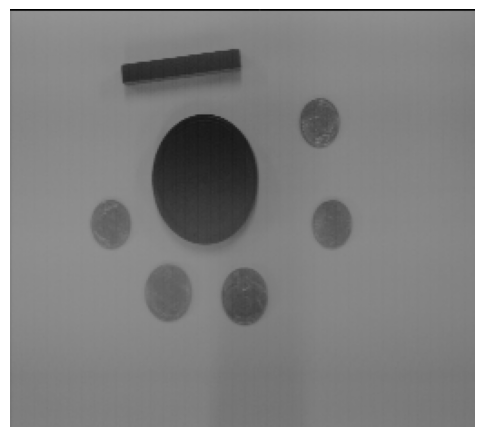

In [25]:
morpho_image = cv2.imread(images_path + "MORPHO.png", cv2.IMREAD_GRAYSCALE)

# visualizar
plt.figure(figsize=(6, 6))
plt.imshow(morpho_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.3 Perturbe (ensucie) la imagen con 25% de ruido “sal y pimienta”. En la imagen ya existen pixeles aberrantes (con intensidades extremas). Esta operación es hecha para amplificar el fenómeno y facilitar la respuesta a la pregunta 9. Nota: El ruido “pimienta y sal” está constituido de picos claros y oscuros (cuyos valores se deben definir en el módulo) con distribución espacial aleatoria. 25 % de pixeles perturbados por este ruido son suficientes para que la imagen morpho.png sea bastante degradada.

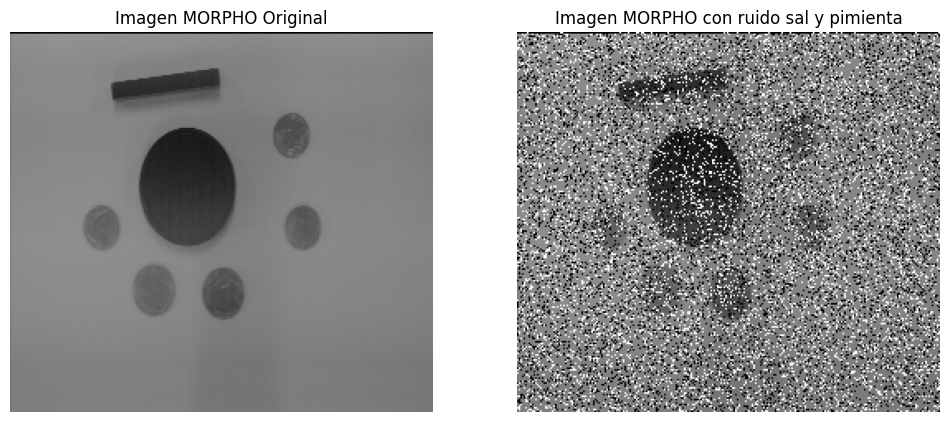

In [31]:
# ruido sal y pimienta aleatorio
morpho_sp = random_noise(morpho_image, mode='s&p', amount=0.25)

# visualizar
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(morpho_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen MORPHO Original")
plt.subplot(1, 2, 2)
plt.imshow(morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Imagen MORPHO con ruido sal y pimienta")
plt.show()

### 3.4 Aplique un filtro promedio 3x3 sobre la imagen con ruido. Visualmente, ¿cómo es el resultado y a qué se debe?

/Users/estefanialaverdebecerra/Library/Python/3.14/lib/python/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  exec(code_obj, self.user_global_ns, self.user_ns)


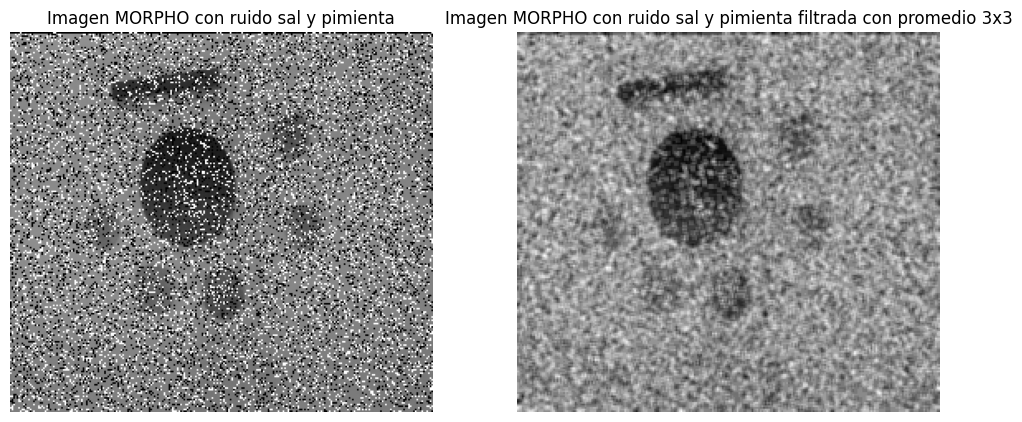

In [32]:
# filtro promedio sobre imagen con ruido
mean_morpho_sp = mean(morpho_sp, footprint_rectangle((3,3)))

# visualizar
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Imagen MORPHO con ruido sal y pimienta")
plt.subplot(1, 2, 2)
plt.imshow(mean_morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Imagen MORPHO con ruido sal y pimienta filtrada con promedio 3x3")
plt.show()

La imagen resultante al aplicar filtro promedio a la imagen con ruido sal y pimienta incorpora dicho tipo de ruido en la imagen con una apariencia más difusa. Esto se debe a que el filtro promedio, al calcular la media de los píxeles vecinos, incorpora la información de los píxeles afectados por el ruido.

### 3.5 Aplique un filtro sigma 3x3 calculando el valor medio a partir pixel central sobre la imagen con ruido. Visualmente, ¿cómo es el resultado comparado con el filtro promedio lineal? Consultando la definición del Sigma explique este resultado. En el caso del ruido “sal y pimienta”, después de aplicar el filtro Sigma, quedan varios puntos aberrantes. ¿A qué se debe esto?

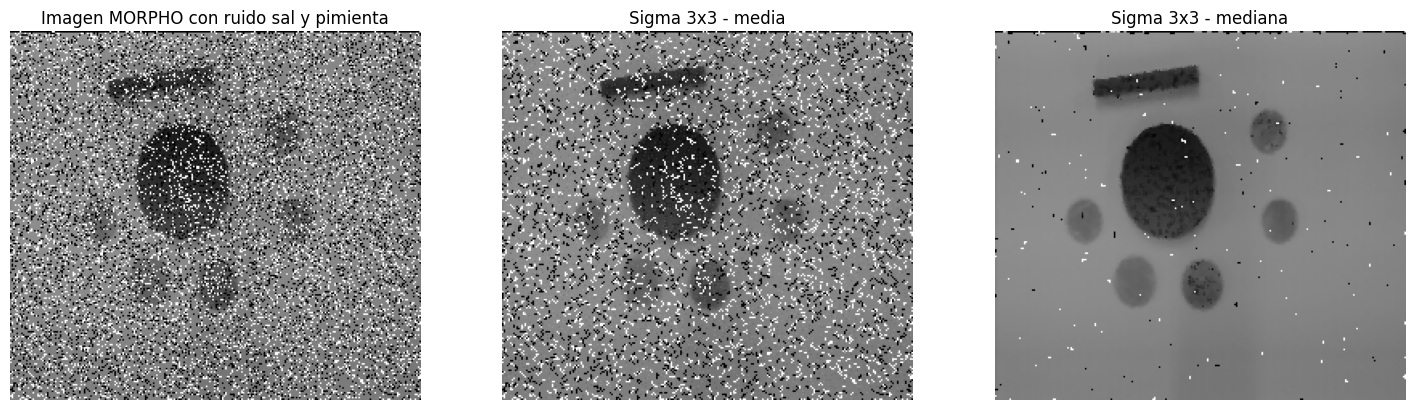

In [55]:
def sigma_filter(values, median=False):
    mean = values[int((values.size)//2)] # obtiene el valor del pixel central
    if median:
      mean = np.median(values) # si es con la mediana, se obtiene el valor mediano del vecindario

    std = np.std(values) # se calcula la desviación estándar del vecindario
    filtered_values = values[(values > mean - std) & (values < mean + std)] # filtra los valores que no están a una desviación estandar de la media
    return np.mean(values) if filtered_values.size<=1 else np.mean(filtered_values) # retorna la media de los valores si el tamaño de los valores filtrados es uno o la media de los valores filtrados


sigma_morpho_sp = generic_filter(morpho_sp, sigma_filter, size=(3,3))
sigma_median_morpho_sp = generic_filter(morpho_sp, sigma_filter, size=(3,3), extra_arguments=(True,))

# visualizar
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Imagen MORPHO con ruido sal y pimienta")
plt.subplot(1, 3, 2)
plt.imshow(sigma_morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Sigma 3x3 - media")
plt.subplot(1, 3, 3)
plt.imshow(sigma_median_morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Sigma 3x3 - mediana")
plt.show()

El resultado del filtro Sigma es visualmente superior al promedio lineal porque logra reducir el ruido sin generar una imagen borrosa que vuelve el ruido parte de la imagen. Mientras que el filtro promedio suaviza los bordes al promediar píxeles del objeto con píxeles del fondo, el filtro Sigma utiliza el valor del píxel central como referencia para definir un "rango de confianza". Al promediar únicamente los píxeles vecinos cuyos niveles de gris caen dentro de una desviación estándar respecto al centro, el filtro excluye los valores que considera atípicos o pertenecientes a una región distinta, preservando así la nitidez de los contornos y la definición de los objetos.

La permanencia de puntos aberrantes se debe a que el filtro Sigma basa sus cálculos en la desviación estándar del vecindario similar al píxel central, lo que hace que si el píxel central está afectado por los valores extremos del ruido, el rango de confianza se desplaza hacia esos valores, permitiendo que se admitan píxeles ruidosos en el promedio o que se quede sin muestras válidas para filtrar, dejando así residuos del ruido.

Por otro lado, al aplicarle la mediana al filtro Sigma, se logra eliminar de mejor manera el ruido de tipo sal y pimienta, ya que no se toma el valor central como referencia para definir el rango de confianza, sino la mediana, lo que hace que los valores extremos del ruido no influyan en el resultado final, logrando así una imagen más limpia y con menos residuos del ruido.

### 3.7 Aplique un filtro mediano 3x3 a la imagen con ruido. Visualmente, ¿cómo es el resultado comparado con los dos filtros anteriores? ¿A qué se debe este resultado? Evalúe los otros filtros que ofrece el módulo filters.rank de scikit-image: majority, maximum, minumum, modal, geometric_mean. Explique su comportamiento.

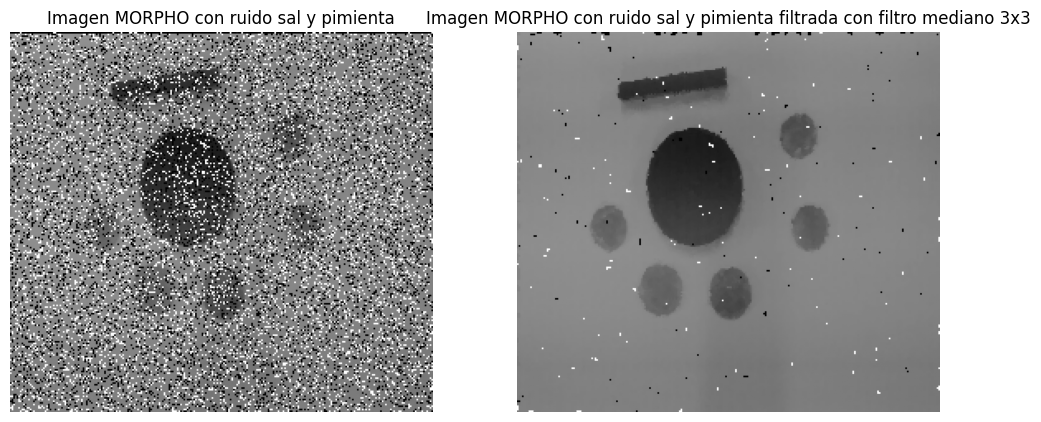

In [40]:
# filtro mediano
median_morpho_sp = median(morpho_sp, footprint_rectangle((3,3)))

# visualizar
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Imagen MORPHO con ruido sal y pimienta")
plt.subplot(1, 2, 2)
plt.imshow(median_morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Imagen MORPHO con ruido sal y pimienta filtrada con filtro mediano 3x3")
plt.show()

/Users/estefanialaverdebecerra/Library/Python/3.14/lib/python/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  exec(code_obj, self.user_global_ns, self.user_ns)


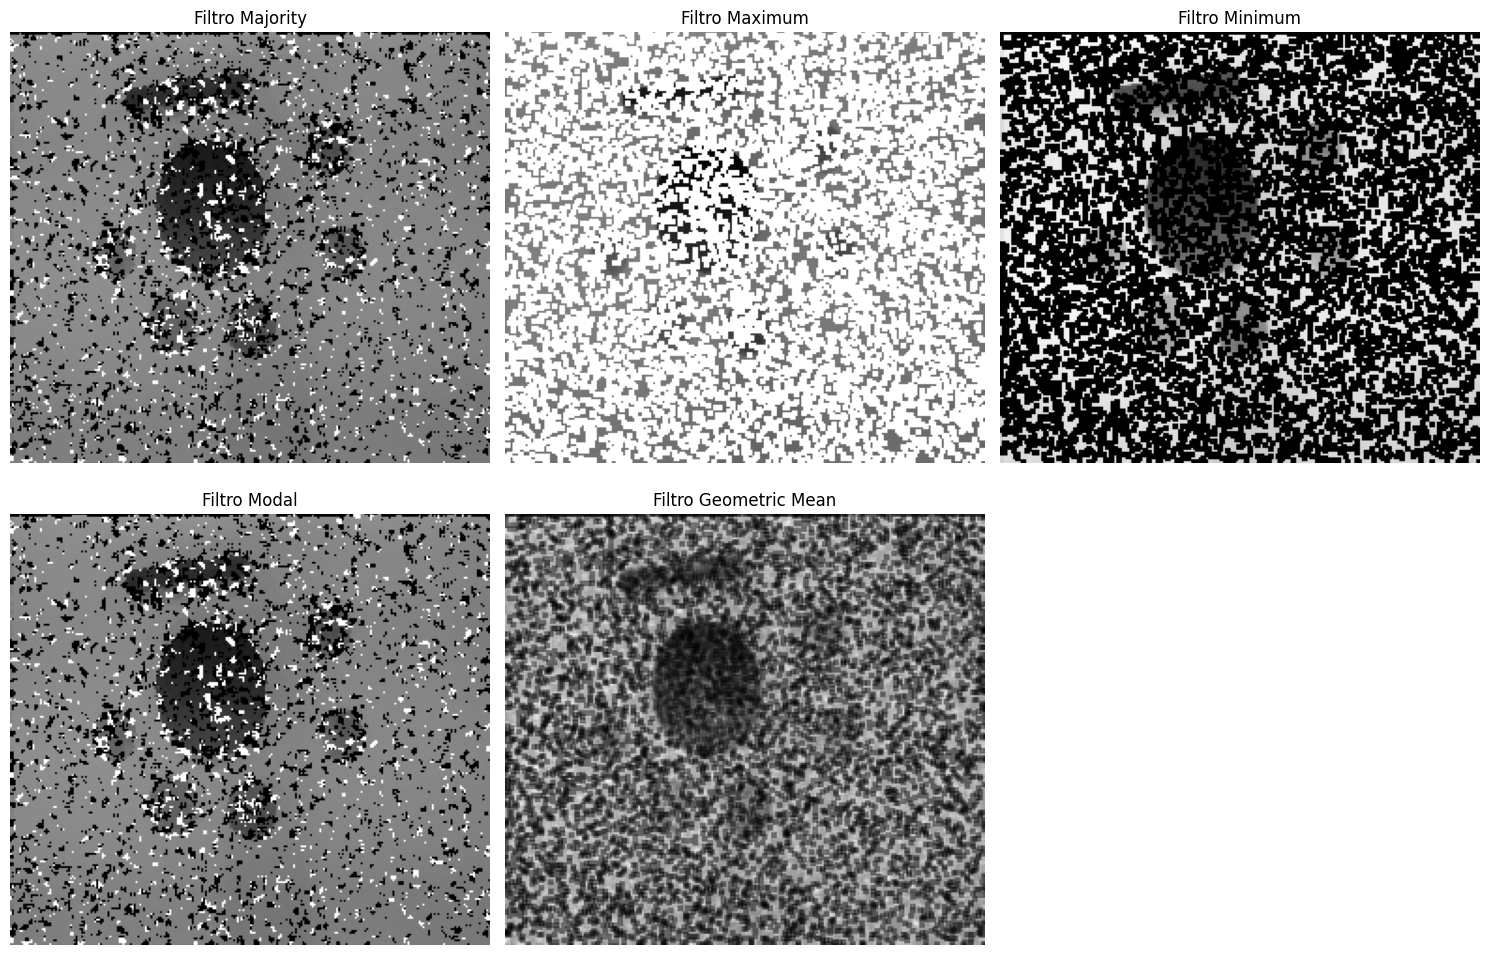

In [50]:
# FILTRO ALTERNATIVOS
# filtro majority
majority_morpho_sp = majority(morpho_sp, footprint_rectangle((3,3)))
# filtro maximum
maximum_morpho_sp = maximum(morpho_sp, footprint_rectangle((3,3)))
# filtro minimum
minimum_morpho_sp = minimum(morpho_sp, footprint_rectangle((3,3)))
# filtro modal
modal_morpho_sp = modal(morpho_sp, footprint_rectangle((3,3)))
# filtro geometric mean
geometric_mean_morpho_sp = geometric_mean(morpho_sp, footprint_rectangle((3,3)))

# visualizar los filtros alternativos
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(majority_morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Filtro Majority")
plt.subplot(2, 3, 2)
plt.imshow(maximum_morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Filtro Maximum")
plt.subplot(2, 3, 3)
plt.imshow(minimum_morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Filtro Minimum")
plt.subplot(2, 3, 4)
plt.imshow(modal_morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Filtro Modal")
plt.subplot(2, 3, 5)
plt.imshow(geometric_mean_morpho_sp, cmap='gray')
plt.axis('off')
plt.title("Filtro Geometric Mean")
plt.tight_layout()
plt.show()

El filtro de mediana de $3 \times 3$ aplicado a la imagen con ruido sal y pimienta produce el mejor resultado visual en comparación con los filtros promedio y Sigma. Esto se debe a que la mediana es un estadístico que ignora valores extremos, seleccionando un valor real de la vecindad en lugar de calcular uno nuevo. A diferencia del filtro promedio o el Sigma, donde los valores 0 o 255 alteran drásticamente el resultado o desplazan el rango de confianza, la mediana permanece inalterada siempre que el ruido no afecte a más de la mitad de los píxeles de la ventana, logrando eliminar los puntos aberrantes sin degradar los bordes de la imagen.

Los otros filtros del módulo filters.rank de scikit-image tienen los siguientes comportamientos:
- **Majority**: Reemplaza el píxel central con el valor que más se repite en el vecindario. Es efectivo para eliminar ruido de tipo sal y pimienta, pero puede generar artefactos si hay múltiples valores con la misma frecuencia.
- **Maximum**: Reemplaza el píxel central con el valor máximo del vecindario. Es útil para resaltar características brillantes, pero puede amplificar el ruido de tipo sal.
- **Minimum**: Reemplaza el píxel central con el valor mínimo del vecindario. Es útil para resaltar características oscuras, pero también puede amplificar el ruido de tipo pimienta.
- **Modal**: Reemplaza el píxel central con el valor modal del vecindario, es decir, el valor que más se repite. Es similar al filtro majority, pero en caso de empate, elige el valor más bajo. Es efectivo para eliminar ruido de tipo sal y pimienta, aunque puede generar artefactos si hay múltiples valores con la misma frecuencia.
- **Geometric Mean**: Reemplaza el píxel central con la media geométrica de los valores de los píxeles vecinos. Es útil para reducir el ruido multiplicativo, pero no es tan efectivo para el ruido de tipo sal y pimienta, ya que los valores extremos pueden influir significativamente en el resultado, generando una imagen con un aspecto más borroso y con residuos del ruido. En el caso del ruido sal y pimienta, si la ventana incluye un solo valor extremo, el resultado será 0 o 255 (multiplicativo, predominando 0), lo que no ayuda a eliminar el ruido.

### 3.8 Repita las operaciones 3 a 6, pero con un ruido uniforme de amplitud 30.

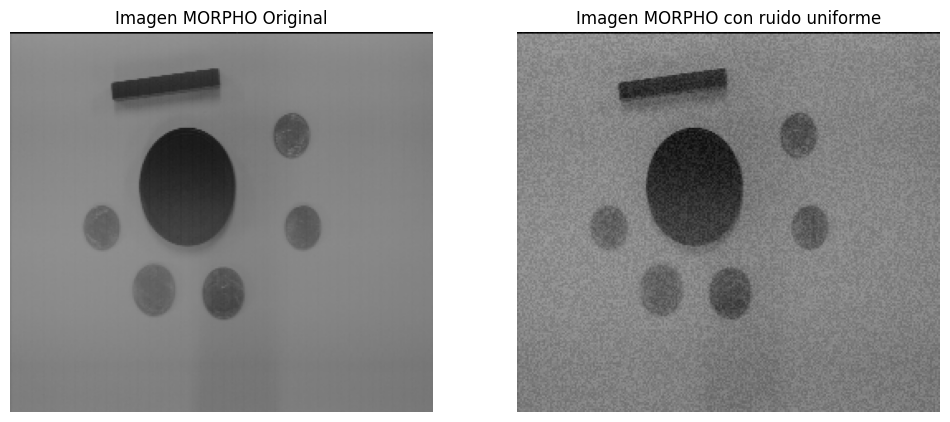

In [41]:
noise = np.random.uniform(low=-15, high=15, size=morpho_image.shape)
uniform_morpho_noise = np.clip(morpho_image.astype(np.float32) + noise, 0, 255).astype(np.uint8) # se trunca a 0-255

# visualizar
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(morpho_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen MORPHO Original")
plt.subplot(1, 2, 2)
plt.imshow(uniform_morpho_noise, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen MORPHO con ruido uniforme")
plt.show()

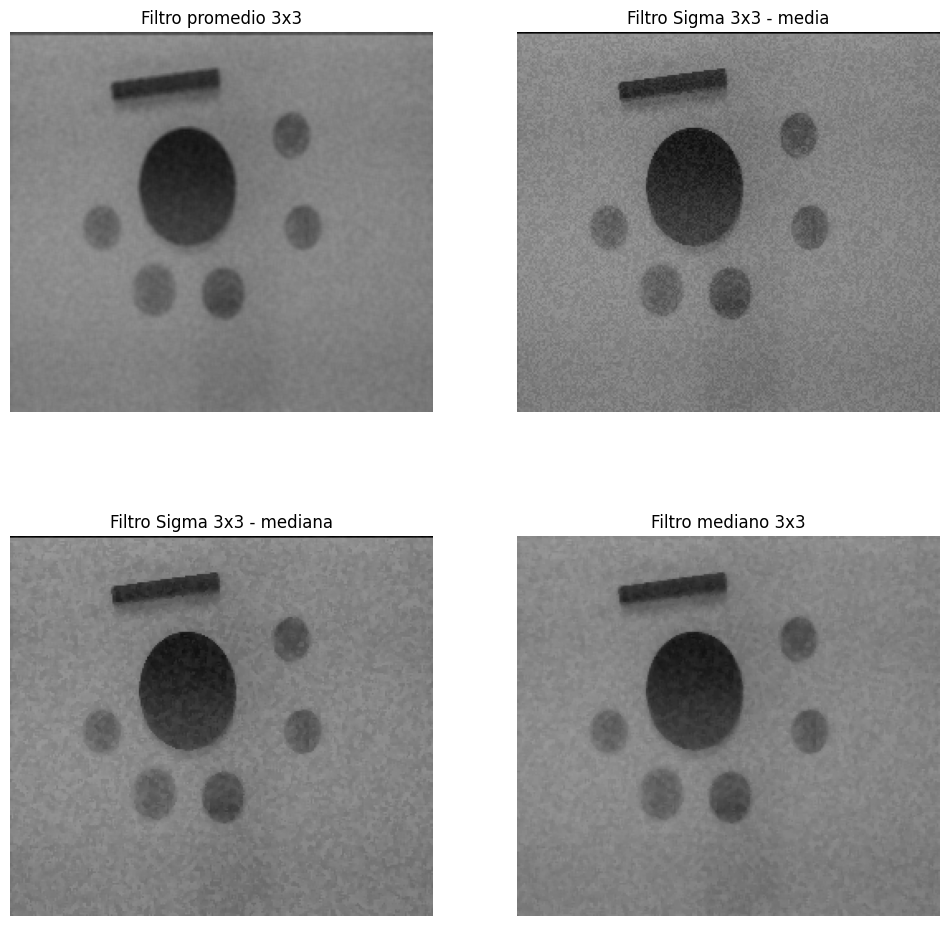

In [58]:
# filtro medio
mean_uniform_morpho = mean(uniform_morpho_noise, footprint_rectangle((3,3)))
# filtro sigma - media
sigma_uniform_morpho = generic_filter(uniform_morpho_noise, sigma_filter, size=(3,3))
# filtro sigma - mediana
sigma_median_uniform_morpho = generic_filter(uniform_morpho_noise, sigma_filter, size=(3,3), extra_arguments=(True,))
# filtro mediano
median_uniform_morpho = median(uniform_morpho_noise, footprint_rectangle((3,3)))

# visualizar
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.imshow(mean_uniform_morpho, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Filtro promedio 3x3")
plt.subplot(2, 2, 2)
plt.imshow(sigma_uniform_morpho, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Filtro Sigma 3x3 - media")
plt.subplot(2, 2, 3)
plt.imshow(sigma_median_uniform_morpho, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Filtro Sigma 3x3 - mediana")
plt.subplot(2, 2, 4)
plt.imshow(median_uniform_morpho, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Filtro mediano 3x3")
plt.show()

Para el caso de ruido uniforme, el filtro promedio de $3 \times 3$ suaviza la imagen, pero no elimina completamente el ruido, ya que el ruido uniforme afecta a todos los píxeles de manera similar, y el promedio puede ser influenciado por estos valores. El filtro Sigma, al basar su cálculo en la desviación estándar, puede reducir algo del ruido, pero no es tan efectivo como en el caso del ruido sal y pimienta, ya que el ruido uniforme no presenta valores extremos que puedan ser fácilmente identificados como atípicos. El filtro de mediana, aunque es robusto contra valores extremos, no es tan efectivo para el ruido uniforme, ya que este tipo de ruido afecta a todos los píxeles de manera similar, lo que hace que la mediana no pueda distinguir entre el ruido y la señal real.

### 3.9 Repita el punto 6 y 7 con la imagen fissure.png.

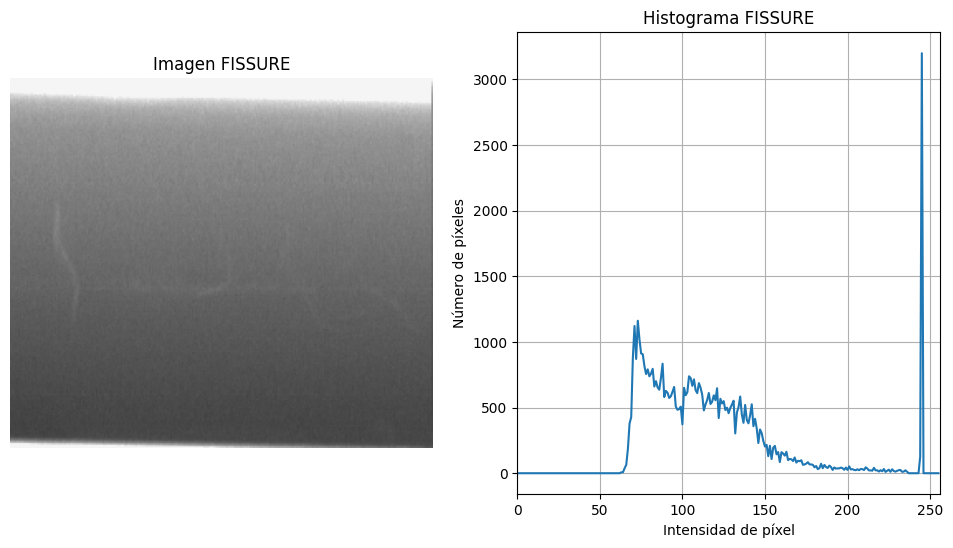

In [47]:
# cargar imagen fissure
fissure_image = cv2.imread(images_path + "FISSURE.png", cv2.IMREAD_GRAYSCALE)

# observar el histograma de la imagen
hist_fissure = cv2.calcHist([fissure_image], [0], None, [256], [0, 256])

# visualizar imagen fissure
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(fissure_image, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen FISSURE")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.plot(hist_fissure)
plt.title("Histograma FISSURE")
plt.xlim([0, 256])
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.grid()
plt.show()

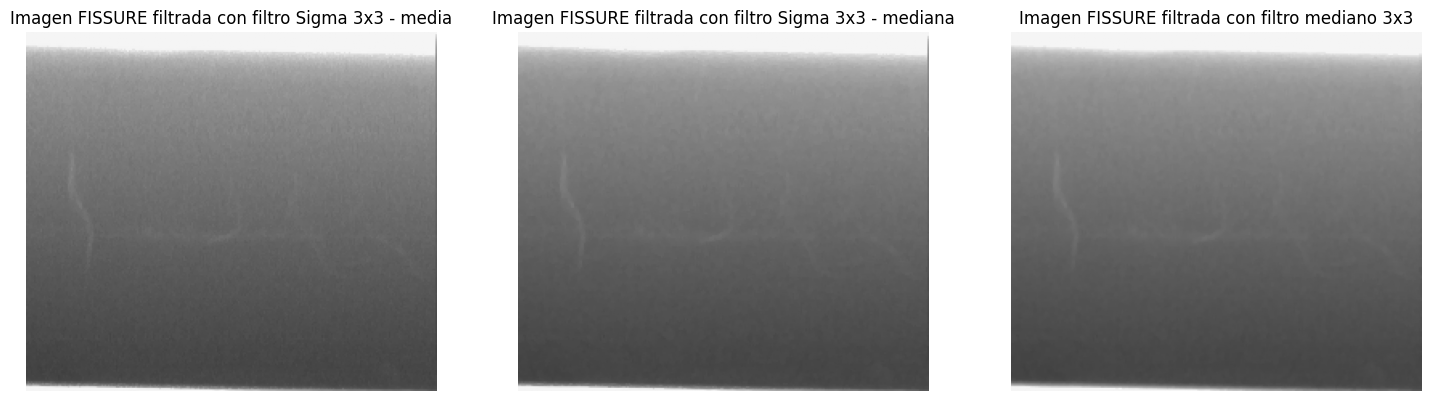

In [60]:
# filtro sigma - media
sigma_fissure = generic_filter(fissure_image, sigma_filter, size=(3,3))
# filtro sigma - mediana
sigma_median_fissure = generic_filter(fissure_image, sigma_filter, size=(3,3), extra_arguments=(True,))
# filtro mediana
median_fissure = median(fissure_image, footprint_rectangle((3,3)))

# visualizar
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(sigma_fissure, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen FISSURE filtrada con filtro Sigma 3x3 - media")
plt.subplot(1, 3, 2)
plt.imshow(sigma_median_fissure, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen FISSURE filtrada con filtro Sigma 3x3 - mediana")
plt.subplot(1, 3, 3)
plt.imshow(median_fissure, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen FISSURE filtrada con filtro mediano 3x3")
plt.show()

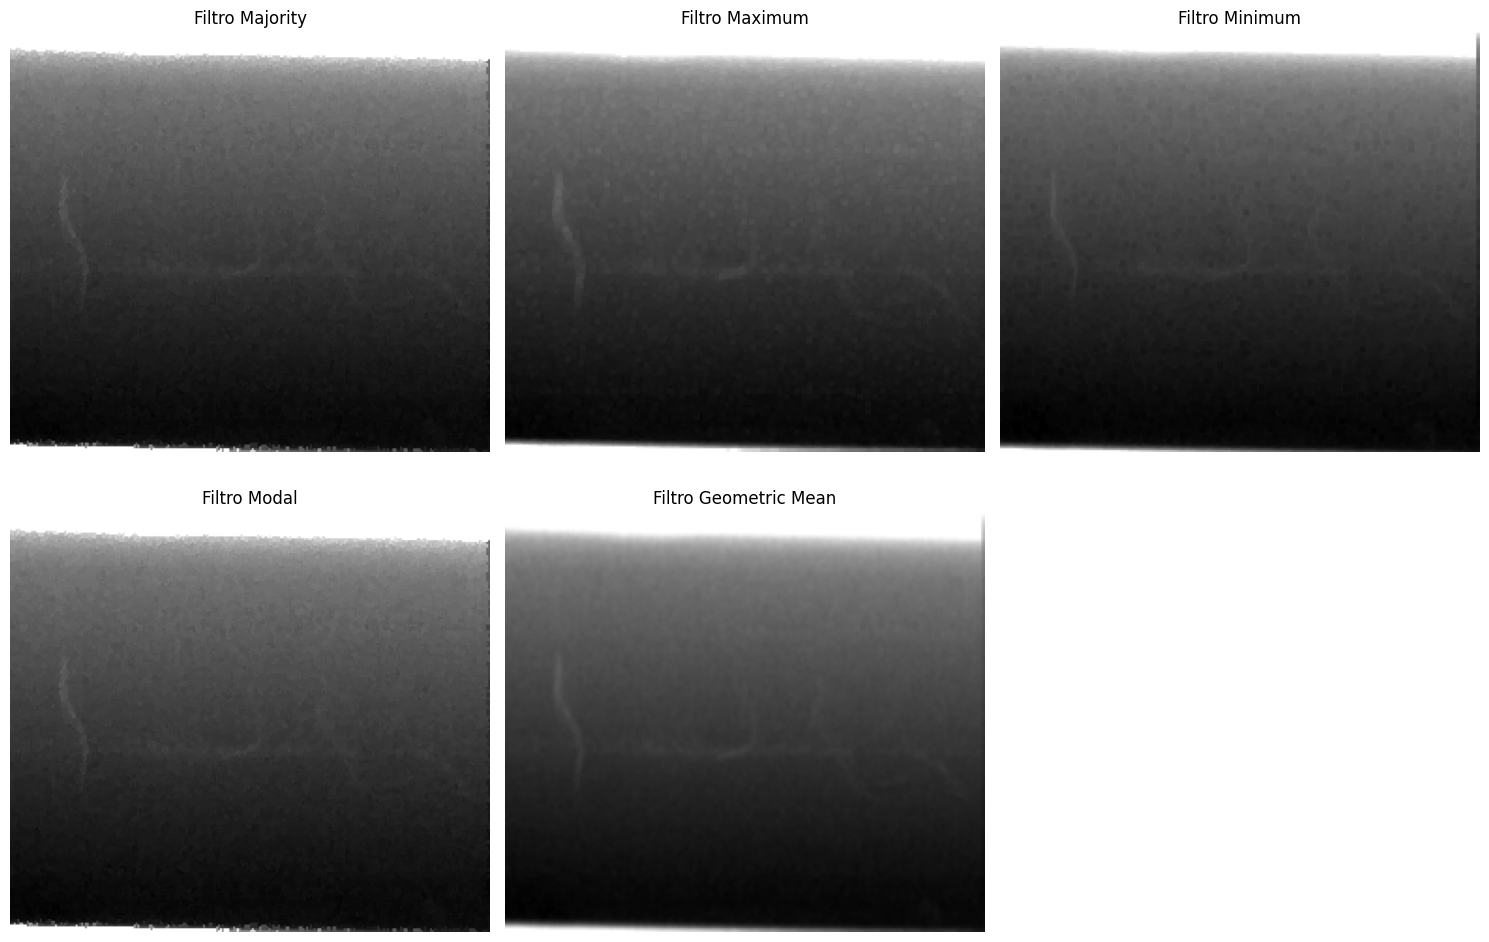

In [51]:
# FILTRO ALTERNATIVOS
# filtro majority
majority_fissure = majority(fissure_image, footprint_rectangle((3,3)))
# filtro maximum
maximum_fissure = maximum(fissure_image, footprint_rectangle((3,3)))
# filtro minimum
minimum_fissure = minimum(fissure_image, footprint_rectangle((3,3)))
# filtro modal
modal_fissure = modal(fissure_image, footprint_rectangle((3,3)))
# filtro geometric mean
geometric_mean_fissure = geometric_mean(fissure_image, footprint_rectangle((3,3)))

# visualizar los filtros alternativos
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(majority_fissure, cmap='gray')
plt.axis('off')
plt.title("Filtro Majority")
plt.subplot(2, 3, 2)
plt.imshow(maximum_fissure, cmap='gray')
plt.axis('off')
plt.title("Filtro Maximum")
plt.subplot(2, 3, 3)
plt.imshow(minimum_fissure, cmap='gray')
plt.axis('off')
plt.title("Filtro Minimum")
plt.subplot(2, 3, 4)
plt.imshow(modal_fissure, cmap='gray')
plt.axis('off')
plt.title("Filtro Modal")
plt.subplot(2, 3, 5)
plt.imshow(geometric_mean_fissure, cmap='gray')
plt.axis('off')
plt.title("Filtro Geometric Mean")
plt.tight_layout()
plt.show()

### 3.10 Compare los resultados obtenidos. Concluya en qué casos (características de la imagen, tipo de ruido, ...) se usan cada uno de estos filtros.

La imagen fissure.png, al tener un detalle muy fino y contraste bajo en la zona del objeto, se beneficia principalmente del filtro geométrico, pues el ruido que posee no es de tipo sal y pimienta, sino que es un ruido más suave que afecta a toda la imagen.

**Casos de uso de filtros**
El filtro de mediana es la mejor opción para procesar imágenes con ruido de tipo sal y pimienta, ya que su capacidad para seleccionar un valor central de la vecindad permite eliminar picos extremos sin degradar los bordes o detalles finos. El filtro Sigma configurado con la mediana ofrece una versatilidad superior, siendo ideal para escenarios de ruido mixto (gaussiano + sal y pimienta por ejemplo), pues logra suprimir valores atípicos manteniendo los tonos de la imagen original. En contraste, el filtro de media geométrica queda limitado a imágenes con ruido muy leve, ya que su naturaleza matemática suaviza la imagen sin llegar a neutralizar efectivamente los valores extremos.

En cuanto a los filtros de rango, el filtro de mayoría (Majority) es preferible para simplificar regiones homogéneas, aunque resulta ineficaz frente a ruidos dispersos como el sal y pimienta debido a su dependencia de la frecuencia local. De manera similar, el filtro modal destaca por su capacidad para preservar estructuras repetitivas y tonalidades dominantes en la vecindad. Finalmente, los filtros de máximo y mínimo cumplen funciones específicas de realce; mientras el primero acentúa las zonas brillantes y el segundo las oscuras, ambos carecen de propiedades para la reducción de ruido, tendiendo más bien a amplificar las perturbaciones en los tonos altos o bajos, respectivamente.

## 4. Síntesis
Utilizando filtros lineales, suavizantes y no lineales, así como cualquier otra operación anterior, el objetivo es tratar de restaurar la imagen a su estado original lo más fiel posible a la original. Un posible resultado aceptable puede ser:

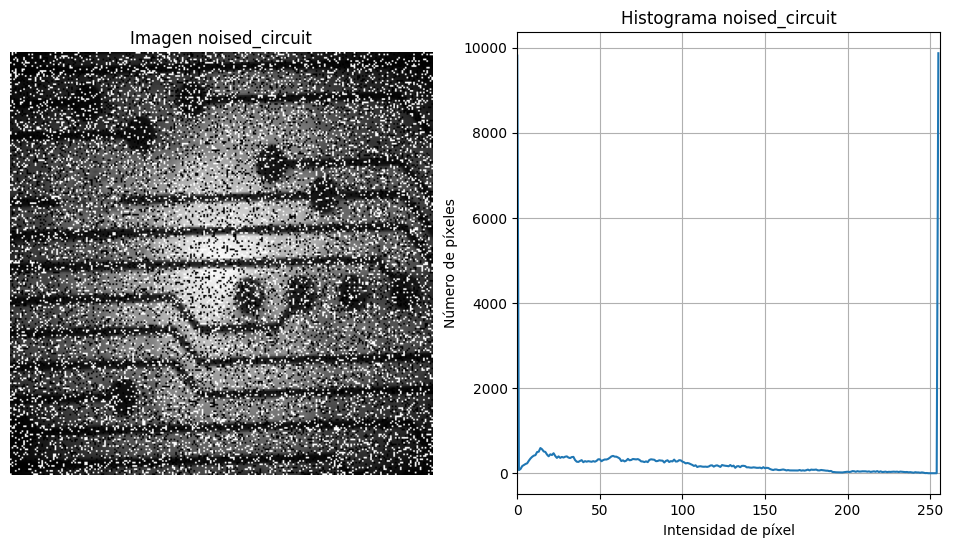

In [103]:
# cargar la imagen noised_circuit
noised_circuit_image = cv2.imread(images_path + "noised_circuit.png", cv2.IMREAD_GRAYSCALE)

# histograma de la imagen noised_circuit
hist_noised_circuit = cv2.calcHist([noised_circuit_image], [0], None, [256], [0, 256])

# visualizar imagen noised_circuit y su histograma
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(noised_circuit_image, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen noised_circuit")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.plot(hist_noised_circuit)
plt.title("Histograma noised_circuit")
plt.xlim([0, 256])
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.grid()
plt.show()

Observamos que el tipo de ruido predominante es el de sal y pimienta, viendose dificultado al tener además sombras circulares.

In [104]:
# funcion de mediana adaptativa
def adaptive_median_filter(image, S_max):
    # padding de 0s para los bordes de la imagen
    output = np.zeros(image.shape, dtype=image.dtype)
    rows, cols = image.shape
    
    for i in range(rows):
        for j in range(cols):
            # la ventana inicia con tamaño 3x3
            k = 1 
            while k <= (S_max // 2):
                # tomo la vecindad actual
                r_min, r_max = max(0, i-k), min(rows, i+k+1)
                c_min, c_max = max(0, j-k), min(cols, j+k+1)
                window = image[r_min:r_max, c_min:c_max]
                
                # cálculo de minimos, máximos, mediana y valor del pixel central
                z_min = np.min(window)
                z_max = np.max(window)
                z_med = np.median(window)
                z_xy = image[i, j]
                
                # etapa A
                a1 = z_med - z_min
                a2 = z_med - z_max
                
                if a1 > 0 and a2 < 0:
                    # etapa B
                    b1 = z_xy - z_min
                    b2 = z_xy - z_max
                    if b1 > 0 and b2 < 0: # si el pixel central no es ruido (no es un valor extremo), se mantiene su valor
                        output[i, j] = z_xy
                    else: # si el pixel central es ruido, se reemplaza por la mediana
                        output[i, j] = z_med
                    break # se encontró una mediana válida, se sale del ciclo
                else:
                    # aumentar el tamaño de la ventana
                    k += 1
            
            # si se alcanza S_max sin encontrar mediana válida, tomo la mediana
            if output[i, j] == 0 and k > (S_max // 2):
                output[i, j] = z_med
                
    return output

Primero, aplicamos la mediana adaptativa para conservar de mejor manera los bordes y detalles de los objetos presentes en la imagen, logrando eliminar la gran mayoría del ruido tipo sal y pimienta.

/var/folders/dj/ljhjywgx7050wg5x_690yv1c0000gn/T/ipykernel_4927/2653350141.py:30: RuntimeWarning: overflow encountered in scalar subtract
  b2 = z_xy - z_max


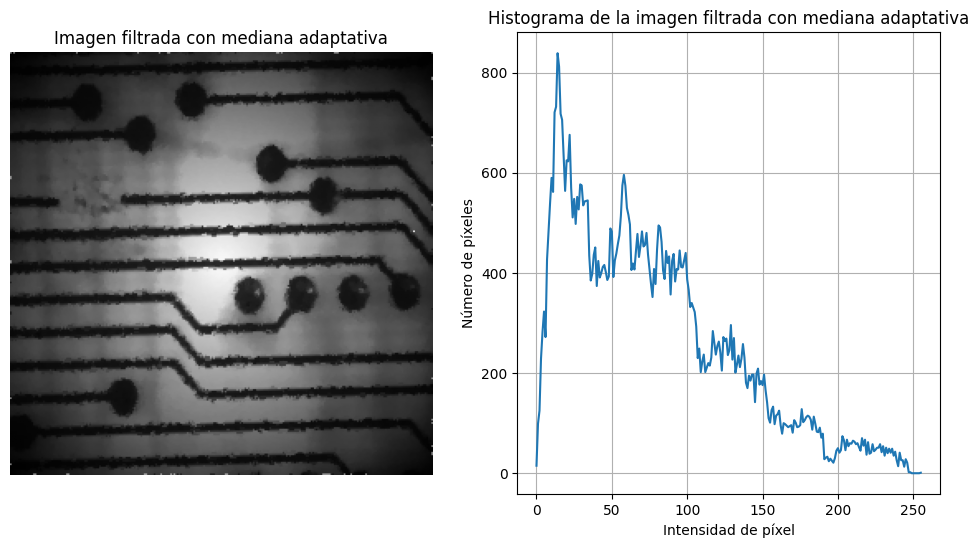

In [118]:
# aplicar el filtro de mediana adaptativa
adaptative_median_noised_circuit = adaptive_median_filter(noised_circuit_image, S_max=5)
histograma_resultado = cv2.calcHist([adaptative_median_noised_circuit.astype(np.uint8)], [0], None, [256], [0, 256])

# visualizar
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(adaptative_median_noised_circuit, cmap="gray")
plt.axis('off')
plt.title("Imagen filtrada con mediana adaptativa")
plt.subplot(1,2,2)
plt.plot(histograma_resultado)
plt.title("Histograma de la imagen filtrada con mediana adaptativa")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.grid()
plt.show()

Los bordes de las líneas negras de la imagen, aunque conservados, se ven afectados por el ruido, lo que hace que hayan quedado residuos del ruido en estas zonas. Para eliminar los residuos, aplicamos un filtro gaussiano que suavice la imagen sin perder la definición de los bordes, logrando así una imagen más limpia y con menos residuos del ruido.

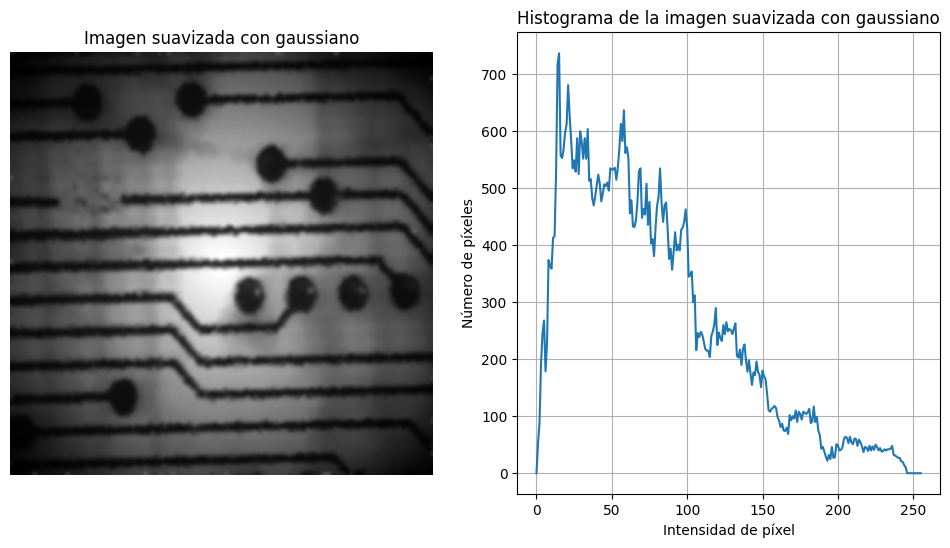

In [119]:
# gaussiano con kernel 5x5 para suavizar el resultado
adaptative_median_noised_circuit = cv2.GaussianBlur(adaptative_median_noised_circuit.astype(np.uint8), (5, 5), 0)
histograma_resultado = cv2.calcHist([adaptative_median_noised_circuit], [0], None, [256], [0, 256])

# visualizar
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(adaptative_median_noised_circuit, cmap="gray")
plt.axis('off')
plt.title("Imagen suavizada con gaussiano")
plt.subplot(1,2,2)
plt.plot(histograma_resultado)
plt.title("Histograma de la imagen suavizada con gaussiano")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.grid()
plt.show()


Para mitigar las sombras radiales y homogeneizar el fondo, se aplicó una corrección de iluminación basada en el filtro Gaussiano; al usar un kernel de dimensiones grandes, se capturan los gradientes globales de luz sin alterar los detalles finos del circuito. Al realizar una división punto a punto entre la imagen original y este mapa de fondo, se normalizan las intensidades locales, compensando las zonas oscurecidas y atenuando los excesos de brillo. Finalmente, se aplica un recorte de valores (clip) y un factor de escala de 0.2, el cual tiene como propósito reubicar el histograma en los tonos bajos para oscurecer el resultado final, logrando así una iluminación uniforme que resalta los detalles del circuito.

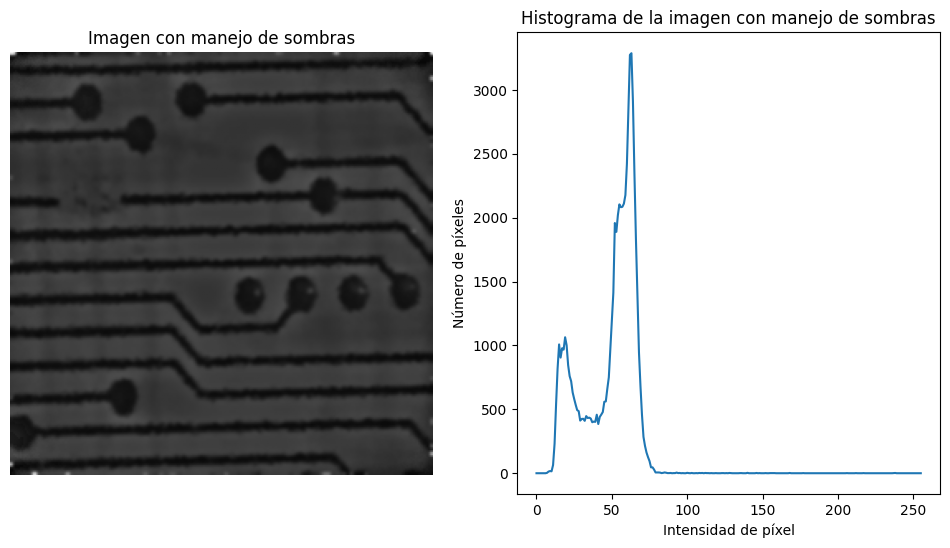

In [120]:
# oscurecer el resultado para mejorar el contraste
iluminacion = cv2.GaussianBlur(adaptative_median_noised_circuit.astype(float), (41, 41), 0)
iluminacion[iluminacion == 0] = 1
adaptative_median_noised_circuit = (adaptative_median_noised_circuit / iluminacion) * (255 * 0.2)
adaptative_median_noised_circuit = np.clip(adaptative_median_noised_circuit, 0, 255).astype(np.uint8)
histograma_resultado = cv2.calcHist([adaptative_median_noised_circuit], [0], None, [256], [0, 256])

# visualizar
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(adaptative_median_noised_circuit, cmap="gray", vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen con manejo de sombras")
plt.subplot(1,2,2)
plt.plot(histograma_resultado)
plt.title("Histograma de la imagen con manejo de sombras")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.show()

Como la imagen quedó concentrada en valores de gris oscuros, se aplica una expansión del contraste.

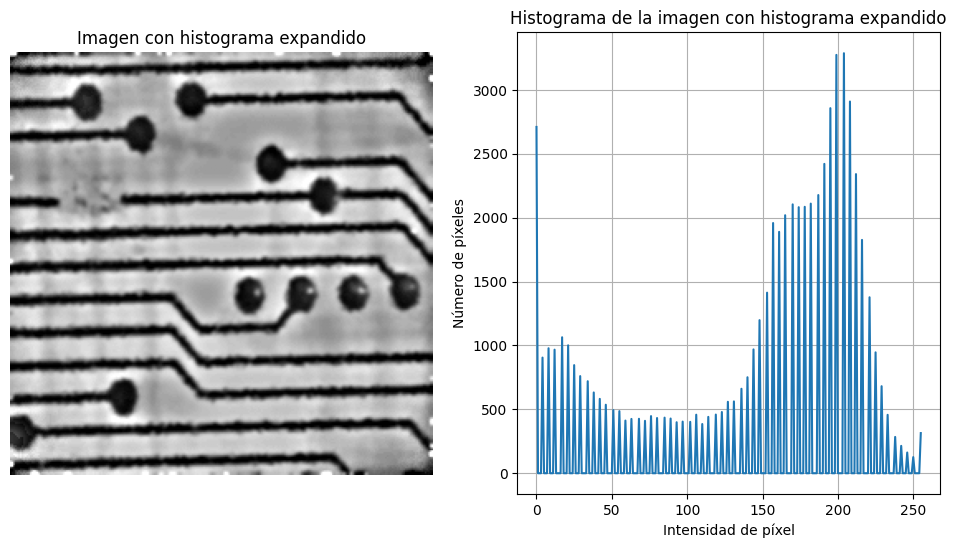

In [108]:
# expandir el histograma para mejorar el contraste
adaptative_median_noised_circuit_ex = adaptative_median_noised_circuit_ex = exposure.rescale_intensity(adaptative_median_noised_circuit, in_range=(15, 75), out_range=(0, 255)).astype(np.uint8)

# visualizar
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(adaptative_median_noised_circuit_ex, cmap="gray", vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen con histograma expandido")
plt.subplot(1,2,2)
plt.plot(cv2.calcHist([adaptative_median_noised_circuit_ex], [0], None, [256], [0, 256]))
plt.title("Histograma de la imagen con histograma expandido")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.grid()
plt.show()

De esta manera, se logra restaurar la iamgen sin perder los detalles de los objetos presentes.